<a href="https://colab.research.google.com/github/ruslanleker1663/MLBB-MachineLearningBelajarBareng/blob/main/MLBB001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

step 1 - loading data

In [18]:
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

In [19]:
df.head(100)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
0,-122.05,37.37,27.0,3885.0,661.0,1537.0,606.0,6.6085,344700.0
1,-118.30,34.26,43.0,1510.0,310.0,809.0,277.0,3.5990,176500.0
2,-117.81,33.78,27.0,3589.0,507.0,1484.0,495.0,5.7934,270500.0
3,-118.36,33.82,28.0,67.0,15.0,49.0,11.0,6.1359,330000.0
4,-119.67,36.33,19.0,1241.0,244.0,850.0,237.0,2.9375,81700.0
...,...,...,...,...,...,...,...,...,...
95,-119.82,36.64,30.0,1694.0,312.0,1008.0,321.0,2.2466,96000.0
96,-120.21,36.77,20.0,1745.0,348.0,1093.0,302.0,2.3194,90600.0
97,-120.97,38.42,16.0,1748.0,322.0,4930.0,287.0,4.3029,121900.0
98,-121.19,38.87,20.0,3118.0,500.0,1405.0,519.0,6.0000,209400.0


step 2 - data inspection

In [20]:
df.shape

(3000, 9)

In [21]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           3000 non-null   float64
 1   latitude            3000 non-null   float64
 2   housing_median_age  3000 non-null   float64
 3   total_rooms         3000 non-null   float64
 4   total_bedrooms      3000 non-null   float64
 5   population          3000 non-null   float64
 6   households          3000 non-null   float64
 7   median_income       3000 non-null   float64
 8   median_house_value  3000 non-null   float64
dtypes: float64(9)
memory usage: 211.1 KB


In [22]:
df.isnull().sum()

,0
longitude,0
latitude,0
housing_median_age,0
total_rooms,0
total_bedrooms,0
population,0
households,0
median_income,0
median_house_value,0


In [23]:
df.describe()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,3000.000000,3000.00000,3000.000000,3000.000000,3000.000000,3000.000000,3000.00000,3000.000000,3000.00000
mean,-119.589200,35.63539,28.845333,2599.578667,529.950667,1402.798667,489.91200,3.807272,205846.27500
std,1.994936,2.12967,12.555396,2155.593332,415.654368,1030.543012,365.42271,1.854512,113119.68747
min,-124.180000,32.56000,1.000000,6.000000,2.000000,5.000000,2.00000,0.499900,22500.00000
25%,-121.810000,33.93000,18.000000,1401.000000,291.000000,780.000000,273.00000,2.544000,121200.00000
50%,-118.485000,34.27000,29.000000,2106.000000,437.000000,1155.000000,409.50000,3.487150,177650.00000
75%,-118.020000,37.69000,37.000000,3129.000000,636.000000,1742.750000,597.25000,4.656475,263975.00000
max,-114.490000,41.92000,52.000000,30450.000000,5419.000000,11935.000000,4930.00000,15.000100,500001.00000


step 3 - visual ispection

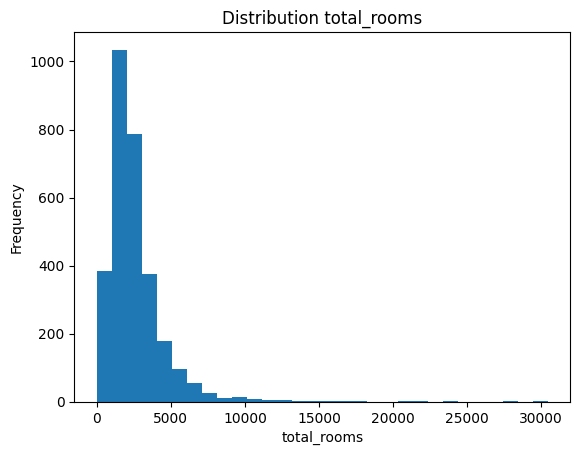

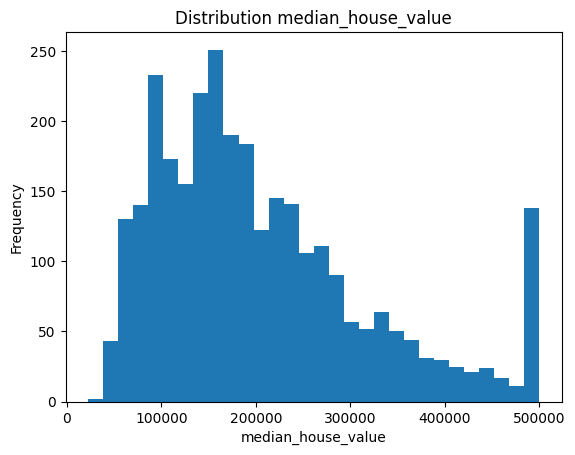

In [24]:
num_cols = ['total_rooms', 'median_house_value']
for col in num_cols:
  plt.figure()
  plt.hist(df[col], bins=30)
  plt.title(f'Distribution {col}')
  plt.xlabel(col);plt.ylabel('Frequency')
  plt.show

In [25]:
import matplotlib.pyplot as plt

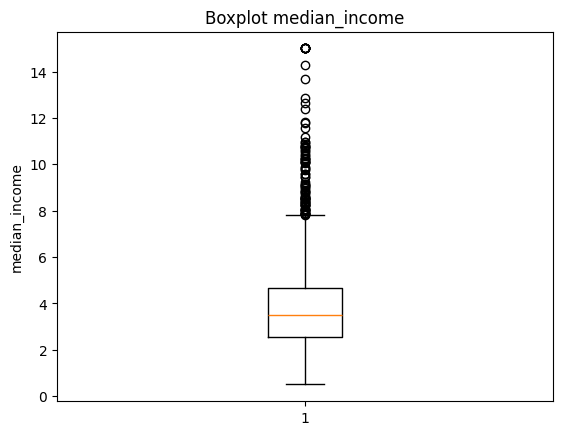

In [26]:
import pandas as pd
df = pd.read_csv('/content/sample_data/california_housing_test.csv')

plt.figure()
plt.boxplot(df['median_income'].dropna(), vert=True)
plt.title('Boxplot median_income')
plt.ylabel('median_income')
plt.show()

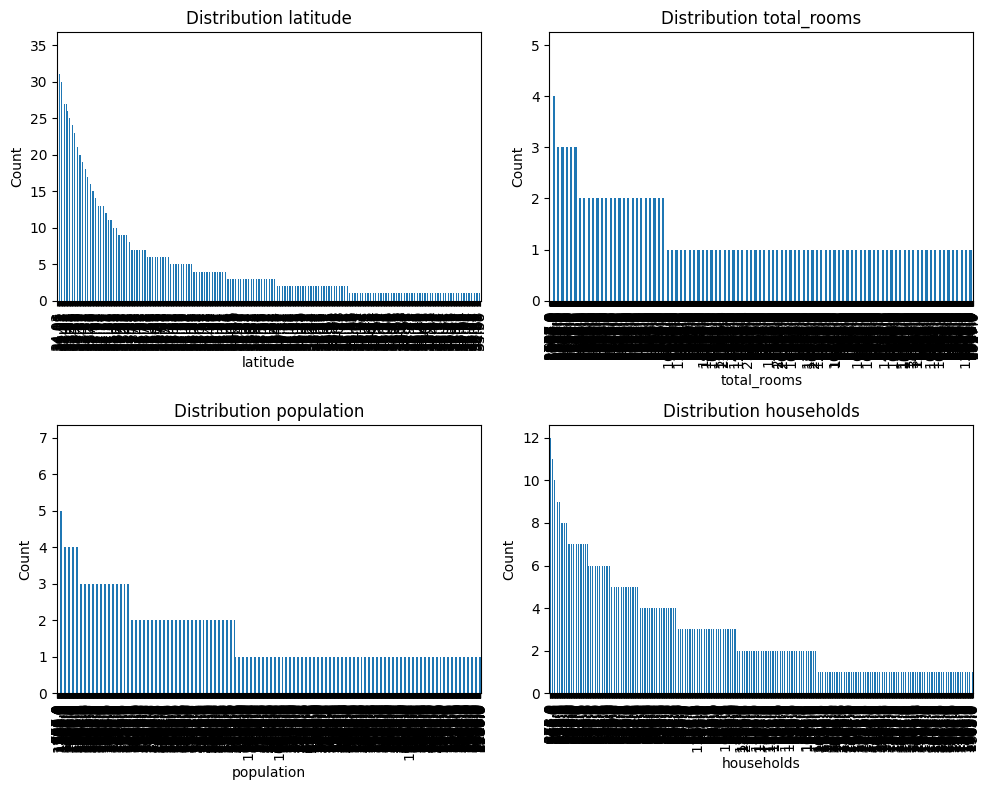

In [12]:
cat_cols = ['latitude', 'total_rooms', 'population', 'households']

fig, axes = plt.subplots(2,2,figsize=(10,8))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
  df[col].value_counts(dropna=False).plot(kind='bar', ax=axes[i])
  axes[i].set_title(f'Distribution {col}')
  axes[i].set_xlabel(col)
  axes[i].set_ylabel('Count')

plt.tight_layout()
plt.show()

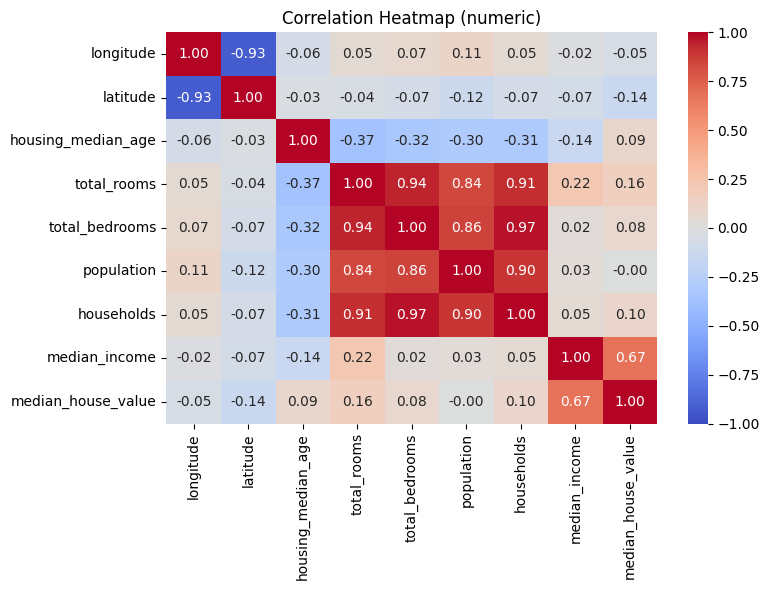

In [13]:
import seaborn as sns # Import seaborn for enhanced visualization

num_only = df.select_dtypes(include=[np.number])
corr = num_only.corr(numeric_only=True)

plt.figure(figsize=(8, 6)) # Increased figure size for better readability
sns.heatmap(corr, cmap='coolwarm', vmin=-1, vmax=1, annot=True, fmt=".2f") # Use seaborn.heatmap with annotation
plt.title('Correlation Heatmap (numeric)')
plt.tight_layout()
plt.show()

In [14]:
corr['latitude'].sort_values(ascending=False)

,latitude
latitude,1.000000
housing_median_age,-0.025143
total_rooms,-0.039632
total_bedrooms,-0.068245
households,-0.068296
median_income,-0.072363
population,-0.117318
median_house_value,-0.138428
longitude,-0.925017


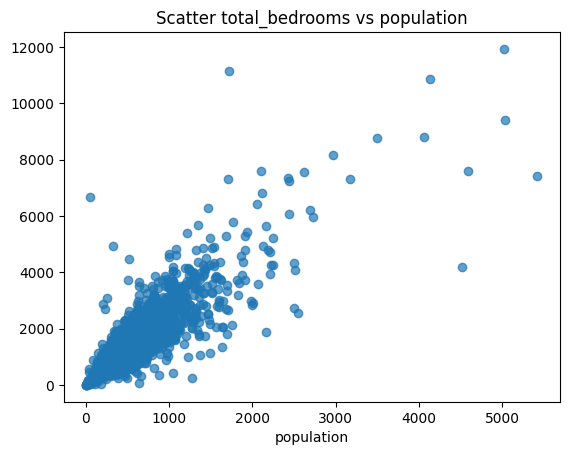

In [15]:
plt.figure()
Surv_map = {0: 'No', 1:'Yes'}
plt.scatter(df['total_bedrooms'], df['population'], alpha=0.7)
plt.xlabel('population')
plt.title('Scatter total_bedrooms vs population')
plt.show()